# Heart Attack Risk Prediction Project

This notebook presents a complete machine learning workflow for predicting heart attack risk using clinical and lifestyle data.  

The analysis includes:

- Loading and understanding the dataset  
- Data cleaning and feature preparation  
- Exploratory data analysis  
- Model training using multiple algorithms  
- Model evaluation and comparison  
- Selection of the best performing model  

In [ ]:
# Import libraries required for the analysis

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [ ]:
# Optional XGBoost import

try:
    from xgboost import XGBClassifier
    xgb_available = True
    print("XGBoost is available and will be included in model comparison.")
except Exception:
    xgb_available = False
    print("XGBoost is not installed. The notebook will continue without it.")


## Load Dataset

The dataset is loaded from a CSV file located in the same directory as the notebook.

In [36]:
# Load dataset

file_path = "heart_attack_prediction_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (8763, 26)


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


## Dataset Inspection

This section examines the structure of the dataset, including column names, data types, and missing values.

In [37]:
# Display column names
print(df.columns)

# Display data types
print(df.dtypes)

# Check missing values
print(df.isnull().sum())


Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')
Patient ID                          object
Age                                  int64
Sex                                 object
Cholesterol                          int64
Blood Pressure                      object
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week        

## Target Variable Distribution

The following output shows the number of records for each class in the target variable.

In [38]:
print(df["Heart Attack Risk"].value_counts())

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64


## Missing Values Check

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values detected in the dataset.")
else:
    display(missing_values.to_frame(name="Missing Count"))


## Target Percentage Distribution

In [ ]:
target_counts = df["Heart Attack Risk"].value_counts().sort_index()
target_percentages = (target_counts / len(df) * 100).round(2)

distribution_df = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage": target_percentages.values
})

display(distribution_df)

plt.figure(figsize=(6, 4))
plt.bar(distribution_df["Class"].astype(str), distribution_df["Percentage"])
plt.title("Target Class Percentage Distribution")
plt.xlabel("Heart Attack Risk")
plt.ylabel("Percentage")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Summary Statistics

Descriptive statistics are calculated to summarise the dataset.  
These statistics include mean, median, standard deviation, minimum and maximum values for numerical variables.

In [68]:
# Summary statistics for numerical variables

df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic_BP,Diastolic_BP
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,...,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,...,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211,135.075659,85.156111
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,...,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502,26.349976,14.676565
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,...,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000,90.000000,60.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,...,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000,112.000000,72.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,...,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000,135.000000,85.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,...,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000,158.000000,98.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,...,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000,180.000000,110.000000


In [70]:
df.median(numeric_only=True)

Age                                    54.000000
Cholesterol                           259.000000
Heart Rate                             75.000000
Diabetes                                1.000000
Family History                          0.000000
Smoking                                 1.000000
Obesity                                 1.000000
Alcohol Consumption                     1.000000
Exercise Hours Per Week                10.069559
Previous Heart Problems                 0.000000
Medication Use                          0.000000
Stress Level                            5.000000
Sedentary Hours Per Day                 5.933622
Income                             157866.000000
BMI                                    28.768999
Triglycerides                         417.000000
Physical Activity Days Per Week         3.000000
Sleep Hours Per Day                     7.000000
Heart Attack Risk                       0.000000
Systolic_BP                           135.000000
Diastolic_BP        

In [71]:
# Frequency counts for categorical variables

print(df["Sex"].value_counts())
print(df["Diet"].value_counts())
print(df["Heart Attack Risk"].value_counts())

Sex
Male      6111
Female    2652
Name: count, dtype: int64
Diet
Healthy      2960
Average      2912
Unhealthy    2891
Name: count, dtype: int64
Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64


## Data Cleaning and Feature Preparation

The blood pressure column contains values such as "120/80".  
This column is separated into two numeric features:

- Systolic Blood Pressure
- Diastolic Blood Pressure

In [39]:
# Split blood pressure column

bp_split = df["Blood Pressure"].str.split("/", expand=True)

df["Systolic_BP"] = pd.to_numeric(bp_split[0], errors="coerce")
df["Diastolic_BP"] = pd.to_numeric(bp_split[1], errors="coerce")

df.drop(columns=["Blood Pressure"], inplace=True)

In [40]:
# Remove identifier column

if "Patient ID" in df.columns:
    df.drop(columns=["Patient ID"], inplace=True)

## Exploratory Data Analysis

The following figures visualise important variables in the dataset.

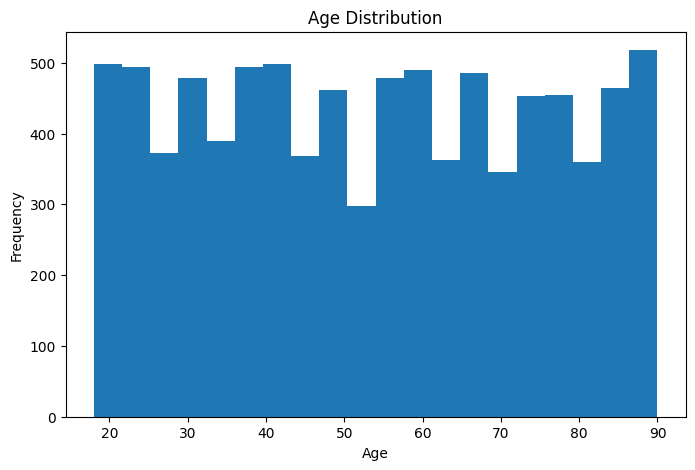

In [41]:
# Age distribution

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

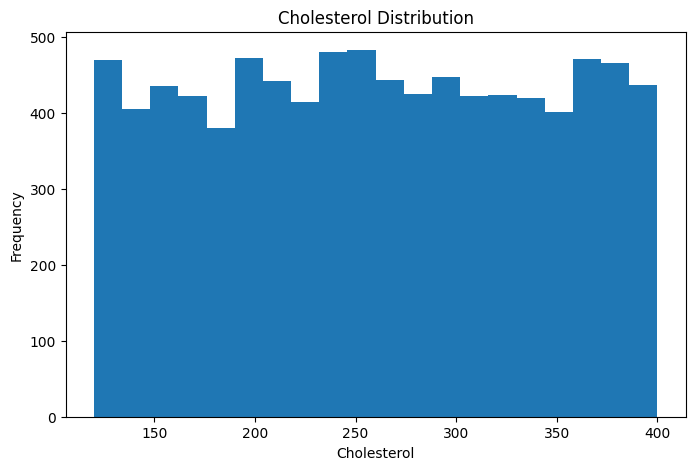

In [42]:
# Cholesterol distribution

plt.figure(figsize=(8,5))
plt.hist(df["Cholesterol"], bins=20)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

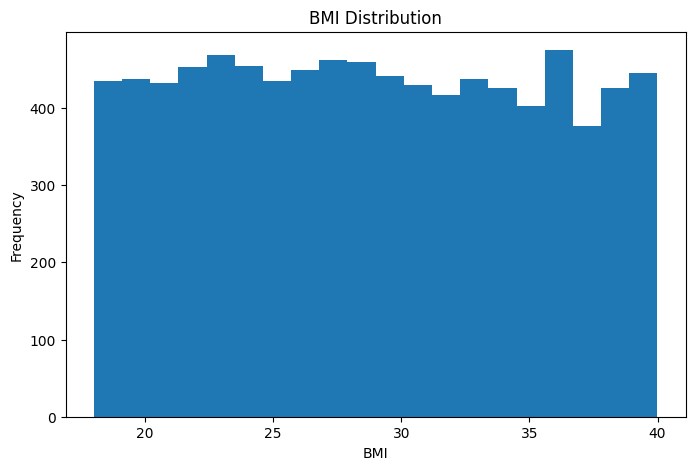

In [43]:
# BMI distribution

plt.figure(figsize=(8,5))
plt.hist(df["BMI"], bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

## Correlation Analysis of Numerical Features

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

if "Heart Attack Risk" in corr_matrix.columns:
    target_corr = corr_matrix["Heart Attack Risk"].sort_values(ascending=False)
    print("Correlation with target:")
    display(target_corr.to_frame(name="Correlation with Heart Attack Risk"))


## Define Features and Target

The dataset is separated into:

- **X** : input features  
- **y** : target variable (Heart Attack Risk)

In [44]:
target_column = "Heart Attack Risk"

X = df.drop(columns=[target_column])
y = df[target_column]

## Identify Numeric and Categorical Variables

Numeric and categorical variables are identified for preprocessing.

In [45]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['Sex', 'Diet', 'Country', 'Continent', 'Hemisphere']
Numeric features: ['Age', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Systolic_BP', 'Diastolic_BP']


## Train-Test Split

The dataset is divided into training and testing sets using an 80/20 split.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Data Preprocessing

Before training machine learning models, the dataset must be prepared.

Two preprocessing steps are applied:

- Numeric variables are imputed and standardised
- Categorical variables are imputed and converted using one-hot encoding

In [47]:
# Preprocessing for numeric features

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [48]:
# Preprocessing for categorical features

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [49]:
# Combine preprocessing steps

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Model Definition

Four machine learning models are used for comparison:

- Logistic Regression  
- Random Forest  
- Gradient Boosting  
- Support Vector Machine

In [ ]:
# Define models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "SVM": SVC(probability=True, random_state=42)
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )

print("Models included in the experiment:")
for name in models:
    print("-", name)


## Model Training and Evaluation

Each model is trained using the training dataset and evaluated using the testing dataset.

The following evaluation metrics are used:

- Accuracy  
- Precision  
- Recall  
- F1 Score  
- ROC-AUC

In [ ]:
# Train models and compute performance metrics

results = []
trained_pipelines = {}

for model_name, model in models.items():

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)

    cv_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    trained_pipelines[model_name] = model_pipeline

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC_AUC": auc,
        "Specificity": specificity,
        "CV_ROC_AUC_Mean": cv_scores.mean(),
        "CV_ROC_AUC_STD": cv_scores.std()
    })

    print(model_name)
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))
    print("ROC-AUC:", round(auc, 4))
    print("Specificity:", round(specificity, 4))
    print("CV ROC-AUC Mean:", round(cv_scores.mean(), 4))
    print("CV ROC-AUC Std:", round(cv_scores.std(), 4))
    print()


## Model Comparison

The evaluation results for all models are summarised in a comparison table.

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["ROC_AUC", "F1 Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

results_df["Rank"] = np.arange(1, len(results_df) + 1)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC_AUC": "{:.4f}",
    "Specificity": "{:.4f}",
    "CV_ROC_AUC_Mean": "{:.4f}",
    "CV_ROC_AUC_STD": "{:.4f}"
}))


## Visual Comparison of Models

In [ ]:
# Accuracy comparison

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# Multi-metric comparison chart

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC_AUC", "Specificity"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Comparison of Classification Metrics Across Models")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## ROC Curve Comparison for All Models

In [ ]:
plt.figure(figsize=(9, 7))

for model_name, pipeline in trained_pipelines.items():
    RocCurveDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        ax=plt.gca(),
        name=model_name
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves for All Models")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Summary Tables for Dissertation Discussion

In [ ]:
top_by_auc = results_df[["Rank", "Model", "ROC_AUC", "F1 Score", "Accuracy", "CV_ROC_AUC_Mean"]]
display(top_by_auc)

results_table_for_report = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC_AUC", "Specificity", "CV_ROC_AUC_Mean", "CV_ROC_AUC_STD"]:
    results_table_for_report[col] = results_table_for_report[col].round(4)

results_table_for_report.to_csv("model_comparison_results.csv", index=False)
print("Saved model comparison table to model_comparison_results.csv")


## Best Model Selection

The best model is selected based on the highest ROC-AUC score.

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("Best Model:", best_model_name)
print()
print("Best model summary:")
display(results_df[results_df["Model"] == best_model_name])


## Detailed Evaluation of the Selected Model

In [ ]:
y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

print("Classification Report")
print(classification_report(y_test, y_pred_best, zero_division=0))


In [ ]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(f"ROC Curve - {best_model_name}")
plt.grid()
plt.tight_layout()
plt.show()


## Feature Importance of the Final Model

In [ ]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title(f"Top 15 Important Features - {best_model_name}")
plt.xlabel("Permutation Importance")
plt.tight_layout()
plt.show()

display(top_features)
importance_df.to_csv("feature_importance_results.csv", index=False)
print("Saved feature importance table to feature_importance_results.csv")


## Save Final Model

In [ ]:
joblib.dump(
    best_model,
    "final_heart_attack_model.pkl"
)

joblib.dump(
    {
        "best_model_name": best_model_name,
        "results_table": results_df,
        "top_features": top_features
    },
    "final_model_metadata.pkl"
)

print("Final model saved as final_heart_attack_model.pkl")
print("Metadata saved as final_model_metadata.pkl")


## Example Prediction

In [64]:
sample = X.iloc[[0]]

prediction = best_model.predict(sample)[0]

probability = best_model.predict_proba(sample)[0][1]

print("Predicted class:", prediction)

print("Predicted probability:", probability)

Predicted class: 0
Predicted probability: 0.125
